# 04 · Coherence and feedback

Part 3 calibrated a pi pulse. Part 4 keeps Part 2's sweeps and Part 3's fits, and brings four more pieces of QProgram.

A **fragment** is a named, parameterised sub-program, so a pulse is written once and called everywhere. One `measure` produces up to three **fields**, and `field=` picks the one you want out of the result. Dropping `average` and sweeping a **shot index** keeps the individual shots instead of their mean. And `if_` opens a **conditional** whose condition is a state a measurement has just classified.

Five experiments carry them. T1, Ramsey and Hahn echo are the same three moves with a different middle, single-shot readout puts two clouds in the IQ plane, and active reset fires a pi pulse only when the qubit came up excited.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import math
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram import fragment
from qprogram.buses import BusSchema
from qprogram.plotting import LIGHT, Quantity, Style
from qprogram.waveforms import IQDrag, IQPair, Square

## 4.0 The device

Same simulated chip as the other parts. `DEVICE` holds the truth the fits have to recover, and the models read it because they stand in for the fridge.

Two entries reach a program rather than a model. `q0_f01` came out of Part 3's two-tone scan and `q0_a_pi` out of its Rabi fit, and both are repeated here so this notebook runs on its own. `DETUNING` puts the drive 400 kHz above the qubit on purpose, which 4.3 needs.

In [3]:
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, at the flux sweet spot
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_T1": 18_000,  # ns
    "q0_T2star": 9_000,  # ns
    "q0_T2echo": 16_000,  # ns
}
DETUNING = 0.4e6  # Hz, how far off the drive frequency is set on purpose

A_PI = DEVICE["q0_a_pi"]
DRIVE_FREQ = DEVICE["q0_f01"] + DETUNING

schema = BusSchema.transmon()
q = schema.q

print(f"pi amplitude {A_PI}, drive set to {DRIVE_FREQ / 1e9:.6f} GHz")
print("truth to recover:", {k: v for k, v in DEVICE.items() if k.startswith("q0_T")})

pi amplitude 0.62, drive set to 4.850400 GHz
truth to recover: {'q0_T1': 18000, 'q0_T2star': 9000, 'q0_T2echo': 16000}


## 4.1 Fragments

A `Fragment` is a named, parameterised sub-program, and `program.call` appends one node for it. Three experiments below play the same two pulses, and writing each pulse once means one definition rather than three copies that drift apart.

The smallest fragment takes the bus it plays on and nothing else.

In [4]:
@fragment
def pi_pulse(f, drive):
    """Part 3's calibrated pi pulse. The first argument is the fragment being built."""
    f.play(drive, IQDrag(amplitude=A_PI, duration=40, sigma=10, beta=0.1))


demo = qp.QProgram(label="fragment_demo", schema=schema)
demo.call(pi_pulse, q[0].drive)

print(pi_pulse)
print(qp.dumps(demo))
print("round trips:", qp.loads(qp.dumps(demo)).body == demo.body)

Fragment('pi_pulse', params=(drive))
#!QProgram 1.0

metadata:
  label: "fragment_demo"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

fragment pi_pulse(drive):
  play drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.1)

body:
  pi_pulse(q[0].drive)

round trips: True


The definition came out as a `fragment` section above `body:`, and the call site stayed one line. Neither half is inlined, and both survive the file, so a reader of the `.qp` sees the structure you wrote.

### Parameters

The first argument is the builder, and every argument after it becomes a `Parameter` in declaration order. The decorator reads a plain positional signature, so a default value or a `*args` is refused at the `def`.

A parameter is an untyped placeholder, so one may stand for a number, a bus, or a waveform, and the binding at the call site decides which. It is also an ordinary expression operand, so arithmetic on it is recorded rather than computed.

The two pulses the rest of the part plays take the amplitude as a parameter, and the pi/2 pulse halves it.

In [5]:
@fragment
def x180(f, drive, amp):
    """A pi pulse."""
    f.play(drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))


@fragment
def x90(f, drive, amp):
    """A pi/2 pulse, the same shape at half the area. `amp` is still the pi amplitude."""
    f.play(drive, IQDrag(amplitude=amp / 2, duration=40, sigma=10, beta=0.1))


print(x180)
print(x90)

pair = qp.QProgram(label="two_calls", schema=schema)
pair.call(x180, q[0].drive, A_PI)  # positional, in declaration order
pair.call(x90, q[0].drive, amp=A_PI)  # or by keyword, Python's own binding rules
print(qp.dumps(pair))

Fragment('x180', params=(drive, amp))
Fragment('x90', params=(drive, amp))
#!QProgram 1.0

metadata:
  label: "two_calls"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

fragment x180(drive, amp):
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)

fragment x90(drive, amp):
  play drive IQDrag(amplitude=(amp / 2), duration=40, sigma=10, beta=0.1)

body:
  x180(q[0].drive, 0.62)
  x90(q[0].drive, 0.62)



The expression survived into the definition as `IQDrag(amplitude=(amp / 2), ...)`, described rather than folded, and the two call sites carry the value.

### The other spelling

`@fragment` reads a function signature and declares the parameters for you. `qp.Fragment(name)` with explicit `parameter()` calls builds the same object by hand, and it is the one to reach for when the parameter list is computed rather than typed out. The two write the same definition, the way Part 2's three sweep spellings built the same tree.

In [6]:
def fragment_section(program):
    """The fragment definitions out of a program's .qp text."""
    text = qp.dumps(program)
    return text[text.index("fragment") : text.index("body:")].rstrip()


by_hand = qp.Fragment("x90")
b_drive = by_hand.parameter("drive")
b_amp = by_hand.parameter("amp")
by_hand.play(b_drive, IQDrag(amplitude=b_amp / 2, duration=40, sigma=10, beta=0.1))

manual = qp.QProgram(label="built_by_hand", schema=schema)
manual.call(by_hand, q[0].drive, A_PI)

decorated = qp.QProgram(label="built_by_decorator", schema=schema)
decorated.call(x90, q[0].drive, A_PI)

print(by_hand)
print("same definition:", fragment_section(manual) == fragment_section(decorated))

Fragment('x90', params=(drive, amp))
same definition: True


### The body runs once

The decorated function is called once, when the decorator runs, and what it records is the AST. Ordinary Python inside the body therefore executes at definition time rather than per call, so a `for` loop writes its copies into the definition and the count is chosen by the code that defines the fragment rather than by the code that calls it.

In [7]:
@fragment
def train(f, drive, amp):
    for _ in range(3):
        f.play(drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))


counted = qp.QProgram(label="train", schema=schema)
counted.call(train, q[0].drive, A_PI)
print(fragment_section(counted))

fragment train(drive, amp):
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)


### `expand()`

What does a call site look like once the definition has been put back into it? `expand()` answers. It returns a new program with every call replaced by a plain `block:` holding the substituted body, and validation and execution run it for you, so it is the thing to print when you want to see what a compiler will get.

`program.fragments` is the registry the `.qp` writer emits its definitions from, and expansion empties it, since an expanded program has no call left to define.

In [8]:
print("fragments registered on the program:", list(pair.fragments))
print("fragments after expand():        ", list(pair.expand().fragments))
print(qp.dumps(pair.expand()).split("body:")[1])

fragments registered on the program: ['x180', 'x90']
fragments after expand():         []

  block:
    play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.1)
  block:
    play q[0].drive IQDrag(amplitude=(0.62 / 2), duration=40, sigma=10, beta=0.1)



Substitution stops at the bound value. The expanded pi/2 pulse reads `amplitude=(0.62 / 2)`, arithmetic still described rather than folded, because folding it would be a decision the compiler has not made yet.

### What expansion renames

Two names inside a fragment cannot survive inlining as they are, and expansion rewrites both.

A fragment declares variables of its own with the same `variable()` call a program uses, and each becomes `{fragment}_{id}` on the host, with a numeric suffix when two calls collide. A measurement's auto-generated name normally embeds its bus, and inside a fragment the bus is still a parameter, so the name is a plain `m0` and repeated calls are suffixed.

The handle lives in the definition, so `measurement_handles()` on the host program sees nothing until you expand. Every experiment below therefore keeps the pulses in fragments and leaves `measure` in the host program, where the handle stays an ordinary Python variable and `result.get(m)` reads the way you wrote it.

In [9]:
@fragment
def gain_ramp(f, bus):
    step = f.variable("step")
    with f.sweep(step, qp.Range(0, 2, 1)):
        f.set_gain(bus, step)


@fragment
def readout_block(f, ro):
    f.play(ro, IQPair(Square(0.2, 2000), Square(0.0, 2000)))
    f.measure(ro, "readout", "weights", fields=(MF.IQ, MF.STATE))


twice = qp.QProgram(label="called_twice", schema=schema)
twice.call(gain_ramp, q[0].drive)
twice.call(gain_ramp, q[0].drive)
twice.call(readout_block, q[0].readout)
twice.call(readout_block, q[0].readout)

expanded = twice.expand()
print("handles before expand:", [h.name for h in twice.measurement_handles()])
print("handles after expand: ", [h.name for h in expanded.measurement_handles()])
print("variables after expand:", [v.id for v in expanded.variables])

handles before expand: []
handles after expand:  ['m0', 'm0_2']
variables after expand: ['gain_ramp_step', 'gain_ramp_step_2']


## 4.2 T1

Excite the qubit, wait, read it out, and sweep the wait. The excited-state population decays as

$$P_1(t) = e^{-t/T_1}.$$

The program is Part 2's sweep with a fragment call in the middle. Two lines are worth pointing at. `wait` takes the swept variable as its duration, and `fields=` accepts as many fields as you want from one `measure`, so this one takes all three. Only `state` is read here, and 4.5 comes back for the other two.

In [10]:
t1 = qp.QProgram(label="t1", description="inversion recovery on q0", schema=schema)
delay = t1.variable("delay", label="Delay", units="ns")
t1_delays = qp.Range(0, 60_000, 1500)  # a bit over three T1, and 1500 divides 60000

with t1.average(shots=400):  # the shots collapse into one number per delay
    with t1.sweep(delay, t1_delays):
        t1.set_frequency(q[0].drive, DEVICE["q0_f01"])
        t1.call(x180, q[0].drive, A_PI)
        t1.wait(q[0].drive, delay)
        t1.sync()
        m_t1 = t1.measure(q[0].readout, "readout", "weights", fields=(MF.STATE, MF.IQ, MF.RAW))

delays = np.array(t1_delays.values())
print(f"{len(delays)} delays from {delays[0]:.0f} to {delays[-1]:.0f} ns")
print("measurement:", m_t1.name)

41 delays from 0 to 60000 ns
measurement: q0/readout/m0


One warning holds for the whole part. **The reference executor has no timing model.** `wait` and `sync` change nothing about the numbers that come back, and the delay reaches the result only because the model reads `env["delay"]`, Part 2's dict of currently bound loop variables.

One model feeds all three fields. `response` gives the noiseless IQ point, which for a dispersive readout sits between the two blob centres at the fraction the population names, and the raw trace is that same point repeated `raw_samples` times. `p_excited` gives the probability that a shot is classified excited, and `state` is one draw against it per shot.

The two kinds of scatter that come back are different, as Part 3 said. `noise=` perturbs the IQ point and leaves the classified outcome alone, so the spread on `iq` is instrumental where the spread on `state` is the binomial one of 400 coin flips.

In [11]:
GROUND = -1.0 - 0.4j  # where a |0> shot lands in the IQ plane
EXCITED = 1.0 + 0.4j  # where a |1> shot lands
AXIS = (EXCITED - GROUND) / abs(EXCITED - GROUND)  # the unit vector between them


def blob(p):
    """The shot-averaged IQ point for an excited-state population `p`."""
    return GROUND + p * (EXCITED - GROUND)


def p_t1(bus, env):
    """T1 (inversion recovery), delay in ns."""
    return np.exp(-env["delay"] / DEVICE["q0_T1"])


t1_result = qp.simulate(
    t1,
    model=qp.MockMeasurementModel(
        response=lambda bus, env: blob(p_t1(bus, env)),
        p_excited=p_t1,
        noise=0.4,
        raw_samples=16,
        seed=17,
    ),
)
population = t1_result.get(m_t1, field=MF.STATE)
print("state field:", population.dims, population.shape)
print("first three points:", np.round(population.values[:3], 3))

state field: ('delay',) (41,)
first three points: [1.    0.912 0.878]


### Drawing it

`result.plot` looks the array up exactly as `result.get` does and lets the shape choose the figure. One swept dimension makes a line.

<Axes: xlabel='Delay (ns)', ylabel='State'>

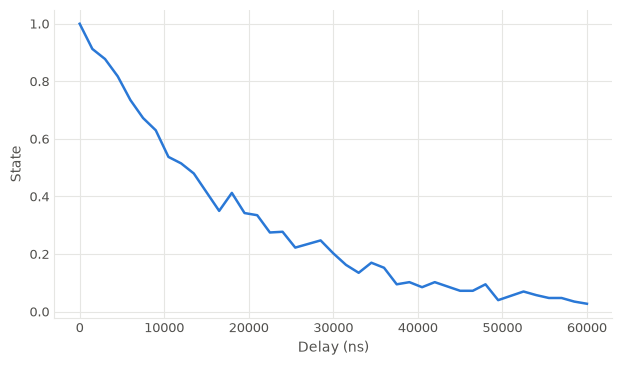

In [12]:
t1_result.plot(m_t1, field=MF.STATE)

Every call hands back the `Axes` it drew on, so the fit goes on top with an ordinary `ax.plot`.

fitted T1 = 18.00 us   true = 18.00 us


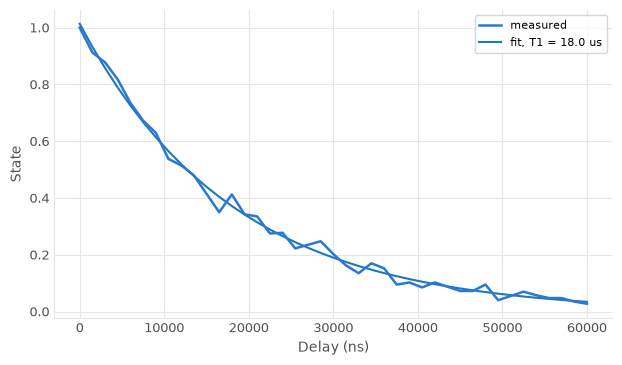

In [13]:
def decay(t, amplitude, tau, offset):
    """An exponential with a free offset. `tau` is the T1 you are after."""
    return amplitude * np.exp(-t / tau) + offset


popt, _ = curve_fit(decay, delays, population.values, p0=[1.0, 10_000.0, 0.0])
t1_fit = popt[1]
print(f"fitted T1 = {t1_fit / 1000:.2f} us   true = {DEVICE['q0_T1'] / 1000:.2f} us")

ax = t1_result.plot(m_t1, field=MF.STATE)
ax.lines[0].set_label("measured")  # a state line comes back unnamed, as Part 3 found
ax.plot(delays, decay(delays, *popt), label=f"fit, T1 = {t1_fit / 1000:.1f} us")
ax.legend(fontsize=8)

Everything past that is the figure rather than the data, and all of it is Part 2's. The delays are stored in nanoseconds and nobody reads a $T_1$ that way, so `coords=` restates the axis in microseconds and the fit line divides by 1000 to follow it.

Both restatements are named once here, because every figure in this part wants the same pair.

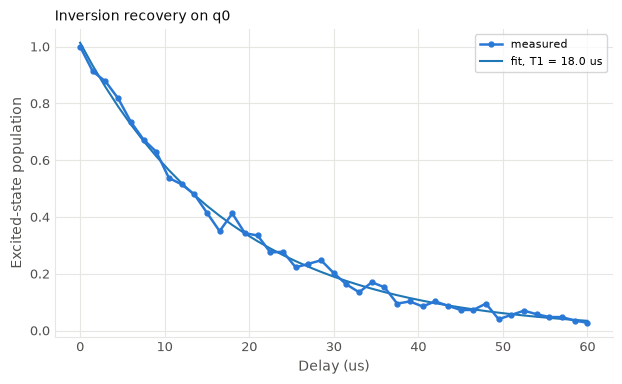

In [14]:
US = Quantity(units="us", transform=lambda v: v / 1000)
POPULATION = Quantity("Excited-state population")

ax = t1_result.plot(
    m_t1,
    field=MF.STATE,
    style=Style(markers=True),  # 41 coarse points: the samples are the measurement
    coords={"delay": US},
    value=POPULATION,
    title="Inversion recovery on q0",
)
ax.lines[0].set_label("measured")
ax.plot(delays / 1000, decay(delays, *popt), label=f"fit, T1 = {t1_fit / 1000:.1f} us")
ax.legend(fontsize=8)

## 4.3 Ramsey

Second middle. Two pi/2 pulses with the wait between them, so the phase the qubit accumulates in the gap comes back as a population, and the result is a fringe at the drive detuning dying out at $T_2^*$:

$$P_1(t) = \tfrac{1}{2}\left(1 + \cos(2\pi \delta t)\right) e^{-t/T_2^*}.$$

Nothing in the program is new. It is the T1 program with a different middle, two `call` lines instead of one, and one field asked for instead of three.

In [15]:
ramsey = qp.QProgram(label="ramsey", description="Ramsey fringe on q0", schema=schema)
r_delay = ramsey.variable("delay", label="Delay", units="ns")

with ramsey.average(shots=400):
    with ramsey.sweep(r_delay, qp.Range(0, 20_000, 125)):
        ramsey.set_frequency(q[0].drive, DRIVE_FREQ)  # deliberately 400 kHz off resonance
        ramsey.call(x90, q[0].drive, A_PI)
        ramsey.wait(q[0].drive, r_delay)
        ramsey.call(x90, q[0].drive, A_PI)
        ramsey.sync()
        m_ramsey = ramsey.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))


def p_ramsey(bus, env):
    """Ramsey with an intentional detuning and exponential decay."""
    t = env["delay"]
    return 0.5 * (1.0 + np.cos(2 * np.pi * DETUNING * t * 1e-9)) * np.exp(-t / DEVICE["q0_T2star"])


ramsey_result = qp.simulate(ramsey, model=qp.MockMeasurementModel(p_excited=p_ramsey, seed=23))
fringe = ramsey_result.get(m_ramsey, field=MF.STATE)
r_delays = fringe.coords["delay"].values
print(f"{len(r_delays)} points, {r_delays[-1] / 1000:.0f} us long, {fringe.dims} {fringe.shape}")

161 points, 20 us long, ('delay',) (161,)


Four parameters to fit, and the fringe frequency is the one that needs a starting guess, since a least-squares cosine started far from the answer walks into a local minimum. Take it from an FFT of the data rather than typing a number, which lands within one bin.

This sweep is dense enough that the markers want to be small, and `Style` takes that as `markersize`.

FFT guess          = 397.5 kHz
fitted T2*         = 9.03 us   true = 9.00 us
fitted detuning    = 399.8 kHz   true = 400.0 kHz


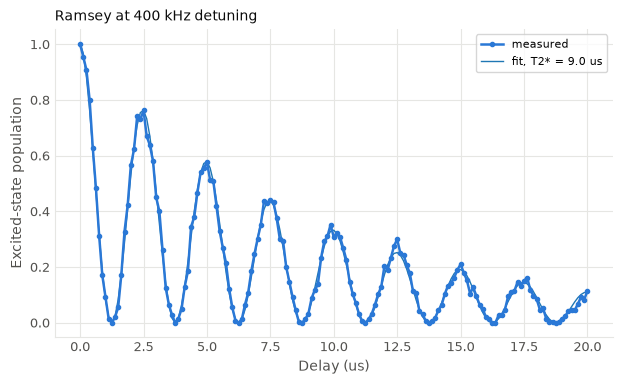

In [16]:
def fringe_model(t, amplitude, tau, freq, phase):
    """A decaying cosine. No constant offset: here the fringe and the mean decay together."""
    return amplitude * np.exp(-t / tau) * (1.0 + np.cos(2 * np.pi * freq * t * 1e-9 + phase))


spectrum = np.abs(np.fft.rfft(fringe.values - fringe.values.mean()))
freq_axis = np.fft.rfftfreq(len(r_delays), d=(r_delays[1] - r_delays[0]) * 1e-9)
freq_guess = freq_axis[spectrum.argmax()]

popt, _ = curve_fit(fringe_model, r_delays, fringe.values, p0=[0.5, 8000.0, freq_guess, 0.0])
t2star_fit, detuning_fit = popt[1], popt[2]
print(f"FFT guess          = {freq_guess / 1e3:.1f} kHz")
print(f"fitted T2*         = {t2star_fit / 1000:.2f} us   true = {DEVICE['q0_T2star'] / 1000:.2f} us")
print(f"fitted detuning    = {detuning_fit / 1e3:.1f} kHz   true = {DETUNING / 1e3:.1f} kHz")

ax = ramsey_result.plot(
    m_ramsey,
    field=MF.STATE,
    style=Style(markers=True, markersize=3),
    coords={"delay": US},
    value=POPULATION,
    title=f"Ramsey at {detuning_fit / 1e3:.0f} kHz detuning",
)
ax.lines[0].set_label("measured")
ax.plot(r_delays / 1000, fringe_model(r_delays, *popt), lw=1, label=f"fit, T2* = {t2star_fit / 1000:.1f} us")
ax.legend(fontsize=8)

The fringe frequency is the error in the drive frequency, so subtracting it tunes the qubit up. That closes the loop 3.1 opened, where a fitted number goes back into the next program as a literal. One caveat rides along: a single Ramsey gives the magnitude of the detuning and not its sign, because cosine is even.

In [17]:
corrected = DRIVE_FREQ - detuning_fit
print(f"drive was at   {DRIVE_FREQ / 1e9:.6f} GHz")
print(f"corrected to   {corrected / 1e9:.6f} GHz")
print(f"true f01 is    {DEVICE['q0_f01'] / 1e9:.6f} GHz")
print(f"residual error {(corrected - DEVICE['q0_f01']) / 1e3:+.1f} kHz")

drive was at   4.850400 GHz
corrected to   4.850000 GHz
true f01 is    4.850000 GHz
residual error +0.2 kHz


## 4.4 Hahn echo

Third middle, and both fragments are in hand. x90, wait, x180, wait, x90, with the pi pulse refocusing whatever held still across the sequence, so what is left is $T_2$:

$$P_1(t) = \tfrac{1}{2} + \tfrac{1}{2} e^{-t/T_2}.$$

The one line 4.4 adds over 4.2 and 4.3 is the half delay. `delay / 2` is an expression, `wait` accepts one wherever a duration goes, and the file records it as written rather than as a number.

In [18]:
echo = qp.QProgram(label="hahn_echo", description="Hahn echo on q0", schema=schema)
e_delay = echo.variable("delay", label="Delay", units="ns")

with echo.average(shots=600):
    with echo.sweep(e_delay, qp.Range(0, 40_000, 800)):
        echo.set_frequency(q[0].drive, DEVICE["q0_f01"])
        echo.call(x90, q[0].drive, A_PI)
        echo.wait(q[0].drive, e_delay / 2)
        echo.call(x180, q[0].drive, A_PI)
        echo.wait(q[0].drive, e_delay / 2)
        echo.call(x90, q[0].drive, A_PI)
        echo.sync()
        m_echo = echo.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

for line in qp.dumps(echo).splitlines():
    if line.strip().startswith(("x90", "x180", "wait")):
        print(line.strip())

x90(q[0].drive, 0.62)
wait q[0].drive (delay / 2)
x180(q[0].drive, 0.62)
wait q[0].drive (delay / 2)
x90(q[0].drive, 0.62)


The offset in the fit is fixed at 0.5 rather than fitted. A refocused curve relaxes to the fully mixed value, you know that number without measuring it, and leaving it free trades it against `tau` for nothing.

fitted T2 = 15.65 us   true = 16.00 us


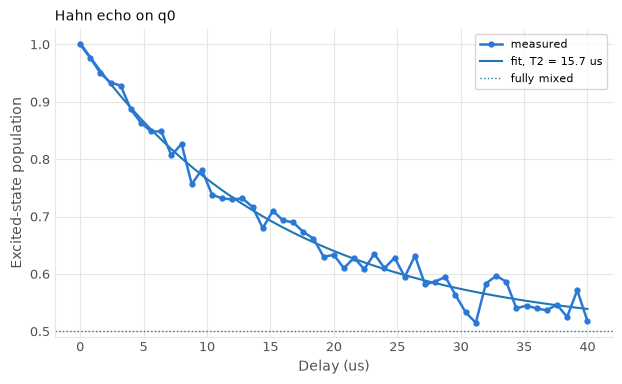

In [19]:
def p_echo(bus, env):
    """Hahn echo: the detuning is refocused, only decay is left."""
    return 0.5 + 0.5 * np.exp(-env["delay"] / DEVICE["q0_T2echo"])


echo_result = qp.simulate(echo, model=qp.MockMeasurementModel(p_excited=p_echo, seed=31))
echo_data = echo_result.get(m_echo, field=MF.STATE)
e_delays = echo_data.coords["delay"].values

echo_fit, _ = curve_fit(
    lambda t, amplitude, tau: 0.5 + amplitude * np.exp(-t / tau),
    e_delays,
    echo_data.values,
    p0=[0.5, 10_000.0],
)
echo_amp, t2_fit = echo_fit
print(f"fitted T2 = {t2_fit / 1000:.2f} us   true = {DEVICE['q0_T2echo'] / 1000:.2f} us")

ax = echo_result.plot(
    m_echo,
    field=MF.STATE,
    style=Style(markers=True),
    coords={"delay": US},
    value=POPULATION,
    title="Hahn echo on q0",
)
ax.lines[0].set_label("measured")
ax.plot(
    e_delays / 1000,
    0.5 + echo_amp * np.exp(-e_delays / t2_fit),
    label=f"fit, T2 = {t2_fit / 1000:.1f} us",
)
ax.axhline(0.5, ls=":", lw=1, label="fully mixed")
ax.legend(fontsize=8)

Three programs, three fits, three numbers. The ordering $T_2^* < T_2 < 2T_1$ follows from arithmetic, so a set that violates it is a bug in the analysis rather than a discovery.

In [20]:
rows = [
    ("T1", t1_fit, DEVICE["q0_T1"]),
    ("T2*", t2star_fit, DEVICE["q0_T2star"]),
    ("T2 (echo)", t2_fit, DEVICE["q0_T2echo"]),
]
print(f"{'quantity':<11}{'fitted':>12}{'true':>12}{'error':>9}")
for name, fitted, true in rows:
    print(f"{name:<11}{fitted / 1000:>9.2f} us{true / 1000:>9.2f} us{100 * (fitted / true - 1):>8.1f}%")
print()
print(f"T2* < T2 < 2*T1 holds: {t2star_fit < t2_fit < 2 * t1_fit}")

quantity         fitted        true    error
T1             18.00 us    18.00 us    -0.0%
T2*             9.03 us     9.00 us     0.4%
T2 (echo)      15.65 us    16.00 us    -2.2%

T2* < T2 < 2*T1 holds: True


## 4.5 The three measurement fields

The T1 program asked for all three. One `measure` call, three arrays, three shapes, and `field=` picks one.

In [21]:
for field in (MF.IQ, MF.STATE, MF.RAW):
    array = t1_result.get(m_t1, field=field)
    print(f"{field:<6} dims={array.dims!s:<26} shape={array.shape}")

iq     dims=('delay', 'IQ')            shape=(41, 2)
state  dims=('delay',)                 shape=(41,)
raw    dims=('delay', 'time', 'IQ')    shape=(41, 16, 2)


The three are points along one pipeline and each throws something away. `raw` is the ADC trace, `iq` is that trace multiplied by the weights and summed, and `state` is `iq` compared against a threshold. Ask for `raw` while you are commissioning a readout and stop once it works, because it is the whole trace rather than one number, and a real acquisition window holds thousands of samples where this model holds sixteen.

The shapes follow from that. `iq` carries an `IQ` axis of length two, `state` carries none at all, since one classified number per point is the whole of it, and `raw` carries a `time` axis whose length is the model's `raw_samples`, an attribute the executor reads once at the start of the run.

`result.get(m)` defaults to `MF.IQ` and raises `KeyError` for a field the measurement never requested. It never substitutes a different array, because a `state` array returned where the caller expected IQ would look like data all the way downstream.

In [22]:
no_iq = qp.QProgram(schema=schema)
m_state_only = no_iq.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
try:
    qp.simulate(no_iq, model=qp.MockMeasurementModel()).get(m_state_only)
except KeyError as exc:
    print("bare get() on a state-only measurement:", exc)

bare get() on a state-only measurement: "Measurement 'q0/readout/m0' has no field 'iq'; available: state"


The extra dimension reaches the figure as well. `state` had one swept dimension and drew a line, `raw` has that dimension and `time`, so the same call draws a heatmap and the field is the only argument that changed. One delay of it is a trace of sixteen samples in two quadratures, which is what the readout chain actually digitised.

one delay of the raw field: ('time', 'IQ') (16, 2)
first three samples: [[0.969 0.383]
 [0.965 0.402]
 [1.002 0.425]]


<Axes: xlabel='time', ylabel='Delay (ns)'>

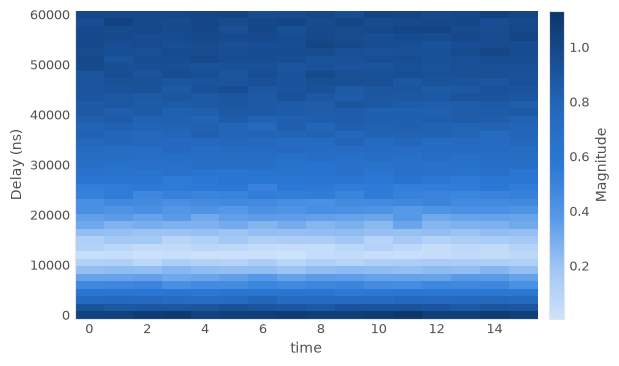

In [23]:
trace = t1_result.get(m_t1, field=MF.RAW).isel(delay=0)
print("one delay of the raw field:", trace.dims, trace.shape)
print("first three samples:", np.round(trace.values[:3], 3))

t1_result.plot(m_t1, field=MF.RAW)

`state` and `iq` are two views of the same shots. The classifier collapsed each shot to a 0 or a 1, so `state` is the population directly, where `iq` has to be projected onto the line between the two blobs first. Both recover T1 to within a few percent, and which of the two lands closer is a property of this seed rather than a rule.

Drawing them together is the case the returned `Axes` was built for. The result can draw its own field and knows nothing about a projection you computed, so the second series goes on with an ordinary `ax.plot`.

T1 from state = 18.00 us
T1 from iq    = 17.69 us


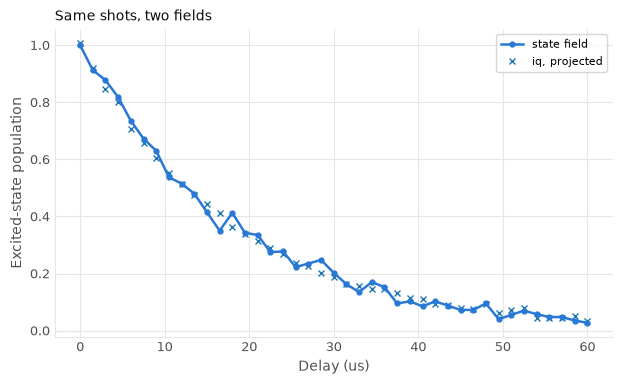

In [24]:
iq = t1_result.get(m_t1)  # default field
z = iq.sel(IQ="I").values + 1j * iq.sel(IQ="Q").values
projected = ((z - GROUND) * np.conj(AXIS)).real / abs(EXCITED - GROUND)

from_state, _ = curve_fit(decay, delays, population.values, p0=[1.0, 10_000.0, 0.0])
from_iq, _ = curve_fit(decay, delays, projected, p0=[1.0, 10_000.0, 0.0])
print(f"T1 from state = {from_state[1] / 1000:.2f} us")
print(f"T1 from iq    = {from_iq[1] / 1000:.2f} us")

ax = t1_result.plot(
    m_t1,
    field=MF.STATE,
    style=Style(markers=True),
    coords={"delay": US},
    value=POPULATION,
    title="Same shots, two fields",
)
ax.lines[0].set_label("state field")
ax.plot(delays / 1000, projected, "x", ms=5, ls="none", label="iq, projected")
ax.legend(fontsize=8)

## 4.6 Single-shot readout

`average(shots)` is the only thing collapsing the shots, and it hands you their mean. To keep them, make the shot index a **sweep variable** and drop the average. Every point then holds exactly one shot, and the result array gains a `shot` dimension.

Nothing reads that variable, and nothing has to. A sweep variable no operation uses still drives its loop.

In [25]:
ground_program = qp.QProgram(label="single_shot_ground", schema=schema)
shot = ground_program.variable("shot", label="Shot index")

with ground_program.sweep(shot, qp.Range(0, 599, 1)):  # 600 points, one shot each, no average
    ground_program.sync()
    m_ground = ground_program.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))

print(qp.dumps(ground_program).split("body:")[1])


  var shot label="Shot index"

  for shot in Range(start=0.0, stop=599.0, step=1.0):
    sync
    measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state", "iq"]



The model changes with the loop. An averaged IQ point was one point on a line, and single shots are two clouds, so `MockMeasurementModel` no longer covers it.

A measurement model is any object with a `sample(bus, env)` method returning a `qp.MeasurementSample`, and `MockMeasurementModel` has been one of those all along. The sample requires `i`, `q` and a classified `state`, and its fourth field, the `raw` trace, is the only one with a default. A model that simulates no ADC leaves `raw` alone and declares no `raw_samples`, which is what the two models below do.

In [26]:
class BlobModel:
    """Single-shot readout: two gaussian clouds in the IQ plane, `p1` of the shots in the upper one."""

    def __init__(self, p1, sigma=0.55, seed=3):
        self.p1, self.sigma = p1, sigma
        self.rng = np.random.default_rng(seed)

    def sample(self, bus, env):
        state = int(self.rng.random() < self.p1)
        center = EXCITED if state else GROUND
        return qp.MeasurementSample(
            i=center.real + self.rng.normal(0, self.sigma),
            q=center.imag + self.rng.normal(0, self.sigma),
            state=state,
        )


one = BlobModel(p1=1.0, seed=0).sample("q0/readout", {})
print(f"one excited shot: I={one.i:+.2f} Q={one.q:+.2f} state={one.state} raw={one.raw.shape}")

ground_run = qp.simulate(ground_program, model=BlobModel(p1=0.02, seed=5))
ground = ground_run.get(m_ground)
print("dims:", ground.dims, ground.shape)
print("no average, so each point is one shot:", np.round(ground.values[:3, 0], 2))

one excited shot: I=+0.93 Q=+0.75 state=1 raw=(0, 2)
dims: ('shot', 'IQ') (600, 2)
no average, so each point is one shot: [-1.73 -0.38 -1.43]


`qp.Repeat` from Part 2 looks like the shorter way to get that dimension and it is not. It multiplies a source's points rather than adding an axis, so `qp.Repeat(qp.Values([0, 1]), times=4)` sweeps eight points on one flattened dimension whose coordinates give no way to tell the repetitions apart. A shot dimension has to come from a loop of its own.

In [27]:
print("Repeat:", qp.Repeat(qp.Values([0, 1]), times=4).values())

Repeat: [0. 1. 0. 1. 0. 1. 0. 1.]


The second program is the first with a pi pulse in front of the readout, so both preparations are in hand. The 2 percent that come out wrong in each run are preparation error, and realistic, because a real pi pulse is never perfect and a real qubit is never perfectly cold.

In [28]:
excited_program = qp.QProgram(label="single_shot_excited", schema=schema)
e_shot = excited_program.variable("shot", label="Shot index")

with excited_program.sweep(e_shot, qp.Range(0, 599, 1)):
    excited_program.call(x180, q[0].drive, A_PI)
    excited_program.sync()
    m_excited = excited_program.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))

excited_run = qp.simulate(excited_program, model=BlobModel(p1=0.98, seed=6))
excited = excited_run.get(m_excited)

# The model reports the true state of each shot, so keep it as the answer key.
truth = np.concatenate(
    [
        ground_run.get(m_ground, field=MF.STATE).values,
        excited_run.get(m_excited, field=MF.STATE).values,
    ]
)
print(f"prepared wrong: {int(truth[:600].sum())} cold shots hot, {int(600 - truth[600:].sum())} hot shots cold")

prepared wrong: 17 cold shots hot, 12 hot shots cold


### The IQ scatter

`kind="scatter"` is the one figure the shape never implies, since plotting I against Q is a choice no dimension count makes for you. It puts I on one axis and Q on the other and flattens everything else into the cloud.

<Axes: xlabel='I', ylabel='Q'>

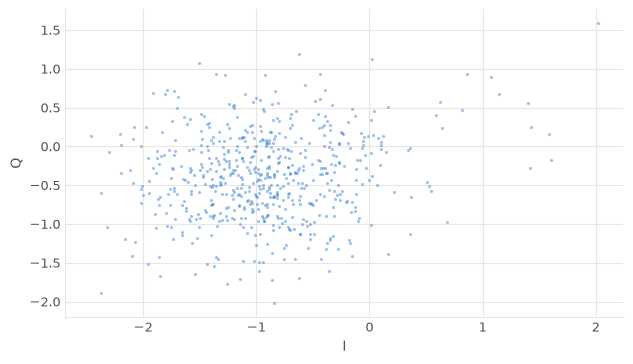

In [29]:
ground_run.plot(m_ground, kind="scatter")

Two clouds means two calls, the second drawing onto the first through `target=`. Both come back in the same colour, for Part 3's reason: the palette does not advance between calls, and each draw starts its colour counter where its own figure declares.

<Axes: xlabel='I', ylabel='Q'>

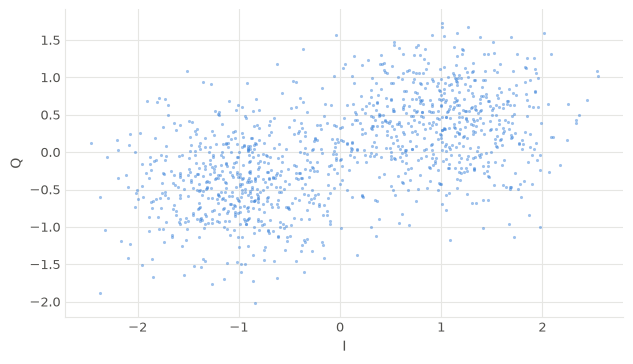

In [30]:
ax = ground_run.plot(m_ground, kind="scatter")
excited_run.plot(m_excited, kind="scatter", target=ax)

Rotating the palette by one slot separates them, and the legend labels go on afterwards, because the two runs are separate results. A scatter refuses a `value=` that carries a label, since its two axes are I and Q and already name themselves, so a name for the figure goes in `title=`. A `Quantity` of `units=` and `transform=` alone is accepted, and restates both quadratures at once.

value= on a scatter: value=Quantity(label=...) names one quantity, and a scatter's two axes are I and Q, which already name themselves — one label on both would hide which is which. Pass units= and transform= to restate the pair, and title= to name the figure.


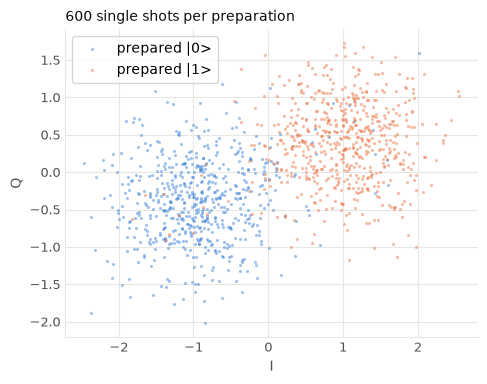

In [31]:
try:
    ground_run.plot(m_ground, kind="scatter", value=POPULATION)
except qp.ValidationError as exc:
    print("value= on a scatter:", exc)

ax = ground_run.plot(m_ground, kind="scatter", title="600 single shots per preparation")
rotated = Style(theme=replace(LIGHT, series=LIGHT.series[1:] + LIGHT.series[:1]))
excited_run.plot(m_excited, kind="scatter", target=ax, style=rotated)
for cloud, label in zip(ax.collections, ("prepared |0>", "prepared |1>"), strict=True):
    cloud.set_label(label)
ax.set_aspect("equal")
ax.legend()

### The threshold

Turning a shot into a bit is a projection onto the line joining the two cloud centres and a threshold at the midpoint. The line here is the simulator's own `GROUND` and `AXIS`, since a stand-in is allowed to know where it put the clouds, and the threshold is read off the two runs. On hardware both come from the data, which makes this a calibration you redo whenever the readout drifts.

Two error numbers come out of it. The **measured** error compares the decision against what you prepared, which is all a lab has, and it charges readout for preparation error too. The **assignment** error compares it against the state each shot was really in, which only the simulator knows.

The histogram is the one figure here that no result can draw. Its x axis is a projection computed from two runs and its y axis is a bin count, so nothing on either result says those numbers belong in one picture, and hand-rolled axes are the right answer.

blob separation  = 3.8 sigma
threshold        = +1.101
measured error   = 5.3%  (readout plus preparation)
assignment error = 3.1%  (readout alone)
gaussian estimate= 2.8%


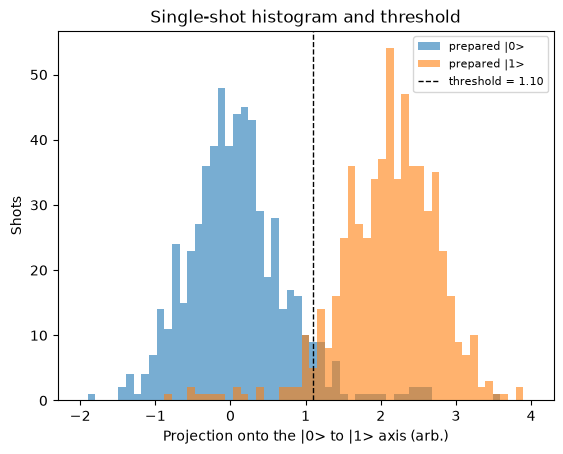

In [32]:
def project(array):
    """Project single shots onto the |0> to |1> axis."""
    z = array.sel(IQ="I").values + 1j * array.sel(IQ="Q").values
    return ((z - GROUND) * np.conj(AXIS)).real


shots = np.concatenate([project(ground), project(excited)])
prepared = np.concatenate([np.zeros(ground.sizes["shot"]), np.ones(excited.sizes["shot"])])
threshold = 0.5 * (shots[prepared == 0].mean() + shots[prepared == 1].mean())
decided = (shots > threshold).astype(float)

separation = shots[truth == 1].mean() - shots[truth == 0].mean()
sigma = 0.5 * (shots[truth == 0].std() + shots[truth == 1].std())
print(f"blob separation  = {separation / sigma:.1f} sigma")
print(f"threshold        = {threshold:+.3f}")
print(f"measured error   = {100 * (decided != prepared).mean():.1f}%  (readout plus preparation)")
print(f"assignment error = {100 * (decided != truth).mean():.1f}%  (readout alone)")
print(f"gaussian estimate= {100 * 0.5 * math.erfc(separation / (2 * np.sqrt(2) * sigma)):.1f}%")

bins = np.linspace(-2.0, 4.0, 60)
_, ax = plt.subplots()
ax.hist(shots[prepared == 0], bins=bins, alpha=0.6, label="prepared |0>")
ax.hist(shots[prepared == 1], bins=bins, alpha=0.6, label="prepared |1>")
ax.axvline(threshold, color="k", ls="--", lw=1, label=f"threshold = {threshold:.2f}")
ax.set_xlabel("Projection onto the |0> to |1> axis (arb.)")
ax.set_ylabel("Shots")
ax.set_title("Single-shot histogram and threshold")
ax.legend(fontsize=8)

## 4.7 Conditionals

`if_`, `elif_` and `else_` are context managers, and they chain the way Python's statements do. The condition is a state a measurement has classified, which makes the handle the one value a branch can read.

The smallest one measures, then plays a pi pulse when the shot came back excited.

In [33]:
branch = qp.QProgram(label="branch_demo", schema=schema)
m_branch = branch.measure(q[0].readout, "readout", "weights", name="check", fields=(MF.STATE,))

with branch.if_(m_branch.state == 1):
    branch.call(x180, q[0].drive, A_PI)

print(qp.dumps(branch).split("body:")[1])


  measure q[0].readout "readout" "weights" name="check" fields=["state"]
  if check.state == 1:
    x180(q[0].drive, 0.62)



`else_` opens the arm for every other outcome, and it has to come immediately after the `if_` it belongs to, because anything appended in between closes the chain.

In [34]:
with branch.else_():
    branch.wait(q[0].drive, 40)

print(qp.dumps(branch).split("body:")[1])


  measure q[0].readout "readout" "weights" name="check" fields=["state"]
  if check.state == 1:
    x180(q[0].drive, 0.62)
  else:
    wait q[0].drive 40



### What a condition may be

One comparison, whose operands are measurement states and integer literals, with at least one measurement state among them. Everything the table lists is that rule, and nothing else is accepted.

| shape | reads as |
|---|---|
| `m.state == 1` | this measurement classified as excited |
| `m.state != 0` | the same thing, spelled the other way |
| `m1.state == m2.state` | two measurements agreed |
| `qp.eq(m.state, 0)`, `qp.ne(m.state, 1)` | the same node, spelled the way Part 2 had to spell it for a variable |

The shape is narrow because a sequencer has to decide between one pulse and the next, while the qubit is still coherent. Comparing one classified bit against a constant fits in that budget and arbitrary arithmetic does not.

A chain shows the rest of the surface. `elif_` takes another condition, the block that comes back holds its arms in source order, and `Conditional.arms` is where a compiler reads them.

In [35]:
chain = qp.QProgram(label="chain_demo", schema=schema)
m_a = chain.measure(q[0].readout, "readout", "weights", name="a", fields=(MF.STATE,))
m_b = chain.measure(q[1].readout, "readout", "weights", name="b", fields=(MF.STATE,))

with chain.if_(qp.eq(m_a.state, 1)):
    chain.call(x180, q[0].drive, A_PI)
with chain.elif_(m_a.state == m_b.state):  # two measurements agreed
    chain.call(x180, q[1].drive, A_PI)
with chain.else_():
    chain.wait(q[0].drive, 40)

conditional = chain.body.elements[2]
print(qp.dumps(chain).split("body:")[1])
print("arms:", len(conditional.arms), "| else:", conditional.else_body is not None)


  measure q[0].readout "readout" "weights" name="a" fields=["state"]
  measure q[1].readout "readout" "weights" name="b" fields=["state"]
  if a.state == 1:
    x180(q[0].drive, 0.62)
  elif a.state == b.state:
    x180(q[1].drive, 0.62)
  else:
    wait q[0].drive 40

arms: 2 | else: True


### Where the rules are enforced

Three checks fire at three different moments, and knowing which is which saves reading the wrong traceback.

`handle.state` refuses the comparison itself when the other side is neither an integer nor another measurement state, so `m.state == 1.0` raises `TypeError` on the line that wrote it, and `m.state > 0` raises before QProgram sees anything, since the proxy implements `==` and `!=` and no other operator. `if_` refuses a condition of the wrong shape at the `with`, which catches a comparison on a swept variable, and catches a `qp.and_` of two perfectly good conditions, because the accepted shape is one comparison rather than something built out of several. A compound test is a second `if_` nested inside the arm.

The third check waits until the program runs. Every measurement a condition references must have asked for `MF.STATE`, and a condition on a classification nobody computed makes the program unexecutable rather than a guess. Part 5 is where that report becomes a tool you can read before running anything.

In [36]:
bad = qp.QProgram(schema=schema)
counter = bad.variable("counter")

try:
    bad.if_(m_branch.state == 1.0)  # a float, not a classified outcome
except TypeError as exc:
    print("at the comparison:", exc)

try:
    with bad.if_(counter > 3):  # not a measurement-state predicate
        bad.play(q[0].drive, "pi")
except qp.ValidationError as exc:
    print("at the with      :", exc)

try:
    with bad.if_(qp.and_(m_branch.state == 1, m_branch.state != 0)):  # two conditions, not one
        bad.play(q[0].drive, "pi")
except qp.ValidationError as exc:
    print("compound         :", exc)

oops = qp.QProgram(schema=schema)
m_no_state = oops.measure(q[0].readout, "readout", "weights")  # default fields=(MF.IQ,)
with oops.if_(m_no_state.state == 1):
    oops.play(q[0].drive, "pi")
try:
    qp.simulate(oops, model=qp.MockMeasurementModel())
except qp.UnsupportedOperationError as exc:
    print("at execution     :", exc)

at the comparison: handle.state can only be compared to int, another handle.<field>, or a MeasurementRef; got float
at the with      : if_() condition must reference at least one measurement-state ref (e.g. `handle.state`); got a comparison of Variable and Constant
compound         : if_() expects a Comparison condition such as `handle.state == 0` or `handle.state != 1`; got LogicalBinaryOp
at execution     : program is not executable on the reference platform:
[error] missing-classification: Conditional references q0/readout/m0.state, but the measurement does not request state classification (add MeasurementField.STATE to fields=) (at body[1])


### NaN in the arm that did not run

**A measurement inside a conditional arm holds NaN wherever the arm never ran.** The averaging is count based, and no executions means no mean. A zero would be indistinguishable from a measurement that ran and came back cold, and any average downstream would quietly include shots that never happened.

Single shots on the sweep axis make that visible, one entry per shot. The program below is the smallest useful branch: measure, and if the qubit came up excited, flip it and look again.

In [37]:
peek = qp.QProgram(label="nan_demo", schema=schema)
peek_shot = peek.variable("shot", label="Shot index")

with peek.sweep(peek_shot, qp.Range(0, 11, 1)):  # 12 shots, small enough to read
    check = peek.measure(q[0].readout, "readout", "weights", name="check", fields=(MF.STATE,))
    with peek.if_(check.state == 1):
        peek.call(x180, q[0].drive, A_PI)
        peek.sync()
        verify = peek.measure(q[0].readout, "readout", "weights", name="verify", fields=(MF.STATE,))

print(qp.dumps(peek).split("body:")[1])


  var shot label="Shot index"

  for shot in Range(start=0.0, stop=11.0, step=1.0):
    measure q[0].readout "readout" "weights" name="check" fields=["state"]
    if check.state == 1:
      x180(q[0].drive, 0.62)
      sync
      measure q[0].readout "readout" "weights" name="verify" fields=["state"]



The executor does not play the pi pulse, so the model keeps that bookkeeping itself. A fresh shot starts hot with probability `p_hot`, and a second measurement inside the same shot happens after the reset pulse has fired, which lands the qubit in the ground state unless the pulse missed. The model is a stand-in, and the program, the conditional and the NaN are the real thing.

In [38]:
class ResetModel:
    """A qubit that is sometimes born hot, and a reset pulse that usually works."""

    def __init__(self, p_hot=0.18, pi_error=0.03, sigma=0.3, seed=11):
        self.p_hot, self.pi_error, self.sigma = p_hot, pi_error, sigma
        self.rng = np.random.default_rng(seed)
        self.shot, self.excited = None, 0

    def sample(self, bus, env):
        if env["shot"] != self.shot:  # a new shot: the qubit arrives however it arrives
            self.shot, self.excited = env["shot"], int(self.rng.random() < self.p_hot)
        elif self.excited:  # a later measurement in the same shot: the pi pulse has fired
            self.excited = int(self.rng.random() < self.pi_error)
        center = EXCITED if self.excited else GROUND
        return qp.MeasurementSample(
            i=center.real + self.rng.normal(0, self.sigma),
            q=center.imag + self.rng.normal(0, self.sigma),
            state=self.excited,
        )


peek_result = qp.simulate(peek, model=ResetModel(seed=0))
print("check :", peek_result.get(check, field=MF.STATE).values)
print("verify:", peek_result.get(verify, field=MF.STATE).values)
print("arm ran on", int(np.isfinite(peek_result.get(verify, field=MF.STATE).values).sum()), "of 12 shots")

check : [0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
verify: [nan  0. nan nan  0.  0. nan nan nan nan nan nan]
arm ran on 3 of 12 shots


### 🧩 Exercise 4.1

That last program is active reset at twelve shots. Passive reset waits several $T_1$ before every shot, and active reset measures instead, firing a pi pulse only when the qubit came up excited.

Run it on 400 single shots and report the excited-state population before and after.

1. One variable `shot`, swept with `qp.Range(0, 399, 1)`, no `average`.
2. `check = program.measure(..., name="check", fields=(MF.STATE,))`.
3. `with program.if_(check.state == 1):` call `x180`, `sync`, and measure again as `"verify"`.
4. `with program.else_():` and `program.wait(q[0].drive, 40)`, 40 being the duration of the pi pulse the other arm plays. A second arm is optional, so write one here and you have used the third context manager.
5. Run it with `ResetModel()` and pull both state arrays.
6. The population before is the mean of `check`. For the population after, remember the NaN: a cold shot never entered the arm, so its outcome is the one `check` already reported, and `np.where(np.isnan(verified), before, verified)` is the whole calculation.

Expect roughly 18 percent before and 1 percent after, the residual being the shots where the pi pulse missed. Call the program `reset` and finish with `print(qp.dumps(reset))`, because the paragraph after this one reads that text.

In [39]:
reset = qp.QProgram(label="active_reset", description="measure, then fix it", schema=schema)
r_shot = reset.variable("shot", label="Shot index")

with reset.sweep(r_shot, qp.Range(0, 399, 1)):
    check = reset.measure(q[0].readout, "readout", "weights", name="check", fields=(MF.STATE,))
    with reset.if_(check.state == 1):
        reset.call(x180, q[0].drive, A_PI)
        reset.sync()
        verify = reset.measure(q[0].readout, "readout", "weights", name="verify", fields=(MF.STATE,))
    with reset.else_():
        reset.wait(q[0].drive, 40)

reset_result = qp.simulate(reset, model=ResetModel())
before = reset_result.get(check, field=MF.STATE).values
verified = reset_result.get(verify, field=MF.STATE).values
after = np.where(np.isnan(verified), before, verified)

print(f"reset fired on {int(np.isfinite(verified).sum())} of {len(before)} shots")
print(f"population before reset = {100 * before.mean():.1f}%")
print(f"population after reset  = {100 * after.mean():.1f}%")
print()
print(qp.dumps(reset))

reset fired on 74 of 400 shots
population before reset = 18.5%
population after reset  = 1.0%

#!QProgram 1.0

metadata:
  label: "active_reset"
  description: "measure, then fix it"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

fragment x180(drive, amp):
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)

body:
  var shot label="Shot index"

  for shot in Range(start=0.0, stop=399.0, step=1.0):
    measure q[0].readout "readout" "weights" name="check" fields=["state"]
    if check.state == 1:
      x180(q[0].drive, 0.62)
      sync
      measure q[0].readout "readout" "weights" name="verify" fields=["state"]
    else:
      wait q[0].drive 40



Read that text once more. The feedback is in the file. `if check.state == 1:` is a statement in a portable text format rather than a vendor call, and the same intent used to be spelled `program.<vendor>.active_reset(...)`, which locked the experiment to one rack. A platform with a hand-tuned reset choreography can still recognise the pattern and lower it to whatever its sequencer does best.

## Recap

- A **fragment** is a parameterised sub-program, written with `@fragment` or built with `qp.Fragment(name)`. The body is recorded once at definition, `call` appends a node, and the `.qp` file carries the definition and the call site apart.
- **`expand()`** inlines every call and renames what it inlines, fragment-local variables onto the host and repeated measurement names apart. Keep `measure` in the host program so the handle stays an ordinary Python variable.
- **`wait` takes an expression.** `wait(bus, delay / 2)` is the only line the echo needed that T1 and Ramsey did not, and the file records the arithmetic rather than a number.
- One `measure` produces up to three **fields**. They are one pipeline, `field=` picks one, a field nobody requested raises rather than substituting, and `raw` carries a `time` axis that turns the same `plot` call from a line into a heatmap.
- Every figure but the histogram came out of `result.plot(...)`, called bare first and dressed afterwards, with the fits and the labels added to the `Axes` it returned.
- Dropping `average` and sweeping a **shot index** keeps the individual shots, and a sweep variable no operation reads still drives its loop.
- **Feedback** is `if_(handle.state == 1)`, with `elif_` and `else_` chaining off it. The condition shape is checked at the comparison, at the `with`, and again before the program runs, and a measurement in an arm that did not run holds NaN.

## Next

Part 5 takes this calibration to a machine where the flux line has no sequencer, and asks what has to change before it runs. The program it carries is one slice of Part 3's flux arc, because that is the one whose loops the new rack has to split between its sequencer and its host, and the exercise puts the second dimension back.